# 02 — Data Preprocessing & Feature Engineering

**Student Academic Risk — Early Intervention System**

This notebook handles:
- Data cleaning (missing values, type corrections)
- Feature engineering (derived metrics)
- Encoding categorical variables
- Feature scaling
- Train/test splitting
- Saving processed data for model training

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
from preprocess import load_raw_data, clean_data, engineer_features, encode_target, get_feature_columns

print('Modules loaded successfully.')

Modules loaded successfully.


## 1. Load Raw Data

In [8]:
import os

def find_project_root():
    curr = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.exists(os.path.join(curr, 'Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx')):
            return curr
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    return os.path.abspath(os.path.join('..', '..'))

PROJECT_ROOT = find_project_root()
DATASET_PATH = os.path.join(PROJECT_ROOT, 'Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx')
df_raw = pd.read_excel(DATASET_PATH)
print(f'Raw dataset loaded from: {DATASET_PATH}')
print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'\nMissing values:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
df_raw.head(3)


Raw dataset loaded from: c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx
Shape: 600 rows × 20 columns

Missing values:
Previous_Semester_GPA    600
dtype: int64


,Enrollment_ID,Student_ID,Gender,Programme,Academic_Year,Semester,Course_ID,Course_Name,Attempt_Number,Enrollment_Type,CA_Score,Assignment_Average,Test_Average,Attendance_Percentage,Number_of_Courses,Previous_Semester_GPA,Previous_Failed_Courses,Final_Exam_Score,Final_Result,Academic_Risk
0,ENR000001,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1101,End User Computing,1,NEW,66.67,61.19,60.82,74.91,5,NaN,0,69.12,PASS,LOW
1,ENR000002,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1102,Introduction to Programming,1,NEW,45.44,48.07,43.71,62.89,5,NaN,0,65.66,PASS,MEDIUM
2,ENR000003,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1103,Computer and Communication Technology,1,NEW,61.09,62.09,52.34,70.10,5,NaN,0,65.85,PASS,LOW


## 2. Data Cleaning

In [9]:
df = df_raw.copy()

# Handle missing Previous_Semester_GPA
# All students are Year 1 Semester 1, so no prior GPA exists. Fill with 0.
print(f'Previous_Semester_GPA missing: {df["Previous_Semester_GPA"].isnull().sum()} / {len(df)}')
df['Previous_Semester_GPA'] = df['Previous_Semester_GPA'].fillna(0.0)

# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

# Verify numeric columns
numeric_cols = ['CA_Score', 'Assignment_Average', 'Test_Average', 
                'Attendance_Percentage', 'Number_of_Courses',
                'Previous_Semester_GPA', 'Previous_Failed_Courses', 'Final_Exam_Score']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'\nAfter cleaning: {df.isnull().sum().sum()} total missing values')
print('✅ Data cleaned successfully.')

Previous_Semester_GPA missing: 600 / 600
Duplicate rows: 0

After cleaning: 0 total missing values
✅ Data cleaned successfully.


## 3. Feature Engineering

In [10]:
# --- Course-level engineered features ---

# Performance Index: weighted average of CA components
df['Performance_Index'] = (
    df['CA_Score'] * 0.4 +
    df['Test_Average'] * 0.3 +
    df['Assignment_Average'] * 0.3
)

# CA-to-Attendance Ratio
df['CA_Attendance_Ratio'] = df['CA_Score'] / (df['Attendance_Percentage'] + 1e-5)

# Threshold flags
df['CA_Below_50'] = (df['CA_Score'] < 50).astype(int)
df['Attendance_Below_70'] = (df['Attendance_Percentage'] < 70).astype(int)

# Score consistency (std of CA, Test, Assignment)
df['Score_Consistency'] = df[['CA_Score', 'Test_Average', 'Assignment_Average']].std(axis=1)

print('Course-level features created:')
print('  ✓ Performance_Index')
print('  ✓ CA_Attendance_Ratio')
print('  ✓ CA_Below_50')
print('  ✓ Attendance_Below_70')
print('  ✓ Score_Consistency')

Course-level features created:
  ✓ Performance_Index
  ✓ CA_Attendance_Ratio
  ✓ CA_Below_50
  ✓ Attendance_Below_70
  ✓ Score_Consistency


In [11]:
# --- Student-level aggregated features ---
student_agg = df.groupby('Student_ID').agg(
    Student_CA_Mean=('CA_Score', 'mean'),
    Student_Attendance_Mean=('Attendance_Percentage', 'mean'),
    Student_Assignment_Mean=('Assignment_Average', 'mean'),
    Student_Test_Mean=('Test_Average', 'mean'),
    Student_Performance_Std=('Performance_Index', 'std'),
    Student_Low_CA_Count=('CA_Below_50', 'sum'),
).reset_index()

df = df.merge(student_agg, on='Student_ID', how='left')

print('\nStudent-level features created:')
print('  ✓ Student_CA_Mean')
print('  ✓ Student_Attendance_Mean')
print('  ✓ Student_Assignment_Mean')
print('  ✓ Student_Test_Mean')
print('  ✓ Student_Performance_Std')
print('  ✓ Student_Low_CA_Count')
print(f'\nTotal features now: {df.shape[1]} columns')


Student-level features created:
  ✓ Student_CA_Mean
  ✓ Student_Attendance_Mean
  ✓ Student_Assignment_Mean
  ✓ Student_Test_Mean
  ✓ Student_Performance_Std
  ✓ Student_Low_CA_Count

Total features now: 31 columns


## 4. Visualize Engineered Features

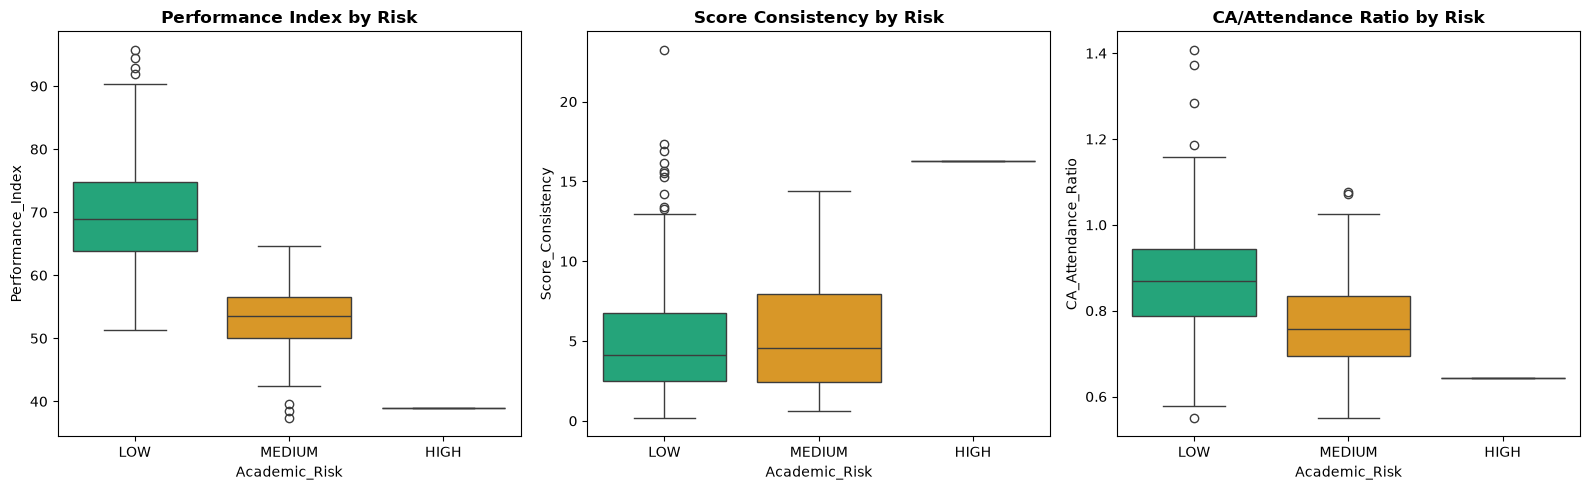

In [12]:
risk_colors = {'LOW': '#10B981', 'MEDIUM': '#F59E0B', 'HIGH': '#EF4444'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Performance Index by risk
order = ['LOW', 'MEDIUM', 'HIGH']
present = [r for r in order if r in df['Academic_Risk'].unique()]
palette = {r: risk_colors[r] for r in present}

sns.boxplot(data=df, x='Academic_Risk', y='Performance_Index', order=present,
           palette=palette, ax=axes[0])
axes[0].set_title('Performance Index by Risk', fontweight='bold')

sns.boxplot(data=df, x='Academic_Risk', y='Score_Consistency', order=present,
           palette=palette, ax=axes[1])
axes[1].set_title('Score Consistency by Risk', fontweight='bold')

sns.boxplot(data=df, x='Academic_Risk', y='CA_Attendance_Ratio', order=present,
           palette=palette, ax=axes[2])
axes[2].set_title('CA/Attendance Ratio by Risk', fontweight='bold')

plt.tight_layout()
plt.savefig('../data_science/data/07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Handle Class Imbalance

The dataset has severe imbalance: LOW=491, MEDIUM=108, HIGH=1.

**Strategy**: Merge HIGH into MEDIUM to create `AT_RISK` class, then use class weighting.

In [13]:
# Create binary risk: LOW vs AT_RISK (MEDIUM + HIGH)
df['Risk_Binary'] = df['Academic_Risk'].map({'LOW': 'LOW', 'MEDIUM': 'AT_RISK', 'HIGH': 'AT_RISK'})

print('Binary risk distribution:')
print(df['Risk_Binary'].value_counts())
print(f'\nAt-risk percentage: {(df["Risk_Binary"] == "AT_RISK").mean() * 100:.1f}%')

# Encode
le_binary = LabelEncoder()
le_binary.fit(['AT_RISK', 'LOW'])
df['Risk_Binary_Encoded'] = le_binary.transform(df['Risk_Binary'])
print(f'\nEncoding: {dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_)))}')

Binary risk distribution:
Risk_Binary
LOW        491
AT_RISK    109
Name: count, dtype: int64

At-risk percentage: 18.2%

Encoding: {np.str_('AT_RISK'): np.int64(0), np.str_('LOW'): np.int64(1)}


## 6. Feature Selection & Train/Test Split

In [14]:
# Define feature columns (exclude target, IDs, and Final_Exam_Score which is not available before the exam)
feature_cols = [
    'CA_Score', 'Assignment_Average', 'Test_Average',
    'Attendance_Percentage', 'Number_of_Courses',
    'Previous_Semester_GPA', 'Previous_Failed_Courses', 'Attempt_Number',
    'Performance_Index', 'CA_Attendance_Ratio',
    'CA_Below_50', 'Attendance_Below_70', 'Score_Consistency',
    'Student_CA_Mean', 'Student_Attendance_Mean',
    'Student_Assignment_Mean', 'Student_Test_Mean',
    'Student_Performance_Std', 'Student_Low_CA_Count',
]

X = df[feature_cols].values
y = df['Risk_Binary_Encoded'].values

print(f'Feature matrix: {X.shape}')
print(f'Target vector: {y.shape}')
print(f'Features used ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

Feature matrix: (600, 19)
Target vector: (600,)
Features used (19):
   1. CA_Score
   2. Assignment_Average
   3. Test_Average
   4. Attendance_Percentage
   5. Number_of_Courses
   6. Previous_Semester_GPA
   7. Previous_Failed_Courses
   8. Attempt_Number
   9. Performance_Index
  10. CA_Attendance_Ratio
  11. CA_Below_50
  12. Attendance_Below_70
  13. Score_Consistency
  14. Student_CA_Mean
  15. Student_Attendance_Mean
  16. Student_Assignment_Mean
  17. Student_Test_Mean
  18. Student_Performance_Std
  19. Student_Low_CA_Count


In [15]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'  - LOW:     {(y_train == le_binary.transform(["LOW"])[0]).sum()}')
print(f'  - AT_RISK: {(y_train == le_binary.transform(["AT_RISK"])[0]).sum()}')
print(f'\nTest set: {X_test.shape[0]} samples')
print(f'  - LOW:     {(y_test == le_binary.transform(["LOW"])[0]).sum()}')
print(f'  - AT_RISK: {(y_test == le_binary.transform(["AT_RISK"])[0]).sum()}')

Training set: 480 samples
  - LOW:     393
  - AT_RISK: 87

Test set: 120 samples
  - LOW:     98
  - AT_RISK: 22


In [16]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied (StandardScaler).')
print(f'Train mean (should be ~0): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Train std  (should be ~1): {X_train_scaled.std(axis=0)[:3].round(4)}')

Feature scaling applied (StandardScaler).
Train mean (should be ~0): [-0.  0. -0.]
Train std  (should be ~1): [1. 1. 1.]


## 7. Save Processed Data

In [17]:
import os
import joblib

processed_dir = os.path.join(PROJECT_ROOT, 'data_science', 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

# Save processed dataframe
df.to_csv(os.path.join(processed_dir, 'processed_data.csv'), index=False)

# Save train/test arrays
np.save(os.path.join(processed_dir, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test_scaled)
np.save(os.path.join(processed_dir, 'y_train.npy'), y_train)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test)

# Save scaler and encoder
models_dir = os.path.join(PROJECT_ROOT, 'data_science', 'models')
os.makedirs(models_dir, exist_ok=True)
joblib.dump(scaler, os.path.join(models_dir, 'scaler.joblib'))
joblib.dump(le_binary, os.path.join(models_dir, 'label_encoder.joblib'))
joblib.dump(feature_cols, os.path.join(models_dir, 'feature_columns.joblib'))

print('✅ All processed data saved:')
print(f'  📁 {processed_dir}/processed_data.csv')
print(f'  📁 {processed_dir}/X_train.npy, X_test.npy, y_train.npy, y_test.npy')
print(f'  📁 {models_dir}/scaler.joblib')
print(f'  📁 {models_dir}/label_encoder.joblib')
print(f'  📁 {models_dir}/feature_columns.joblib')


✅ All processed data saved:
  📁 c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\data_science\data\processed/processed_data.csv
  📁 c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\data_science\data\processed/X_train.npy, X_test.npy, y_train.npy, y_test.npy
  📁 c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\data_science\models/scaler.joblib
  📁 c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\data_science\models/label_encoder.joblib
  📁 c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\data_science\models/feature_columns.joblib
